In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/spotify2026.csv')

df.head()

print(df.columns.tolist())

['Songs & Artist', 'Streams', 'Daily']


In [3]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Songs & Artist', 'Streams', 'Daily']


In [4]:
df[['Artists', 'Track Name']] = df['Songs & Artist'].str.split(' - ', expand=True)
df.drop(columns=['Songs & Artist'], inplace=True)
df.head()

,Streams,Daily,Artists,Track Name
0,"5,34,19,96,137","13,66,661",The Weeknd,Blinding Lights
1,"4,83,44,46,201","13,90,040",Ed Sheeran,Shape of You
2,"4,48,25,25,861","23,67,040",The Neighbourhood,Sweater Weather
3,"4,44,35,48,062","17,94,689",The Weeknd,Starboy
4,"4,32,23,46,703","16,41,116",Harry Styles,As It Was


In [5]:
df.replace(",", "", regex=True, inplace=True)
df.head()

,Streams,Daily,Artists,Track Name
0,5341996137,1366661,The Weeknd,Blinding Lights
1,4834446201,1390040,Ed Sheeran,Shape of You
2,4482525861,2367040,The Neighbourhood,Sweater Weather
3,4443548062,1794689,The Weeknd,Starboy
4,4322346703,1641116,Harry Styles,As It Was


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Streams     2500 non-null   str  
 1   Daily       2498 non-null   str  
 2   Artists     2500 non-null   str  
 3   Track Name  2496 non-null   str  
dtypes: str(4)
memory usage: 179.3 KB


In [7]:
df["Streams"] = df["Streams"].astype(int)
df.dropna(inplace=True)
df["Daily"] = df["Daily"].astype(int)
df.info()

<class 'pandas.DataFrame'>
Index: 2494 entries, 0 to 2499
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Streams     2494 non-null   int64
 1   Daily       2494 non-null   int64
 2   Artists     2494 non-null   str  
 3   Track Name  2494 non-null   str  
dtypes: int64(2), str(2)
memory usage: 155.6 KB


In [8]:
display(df.describe())

,Streams,Daily
count,2.494000e+03,2.494000e+03
mean,1.207710e+09,5.272879e+05
std,6.040810e+08,4.208341e+05
min,6.586277e+08,5.859000e+03
25%,7.861193e+08,2.642102e+05
50%,9.970679e+08,4.251480e+05
75%,1.403832e+09,6.655685e+05
max,5.341996e+09,6.274860e+06


In [9]:
top_artists = df.groupby('Artists')['Streams'].sum().sort_values(ascending=False).head(10)

print("--- Top 10 Artists by Total Streams ---")
print(top_artists)

--- Top 10 Artists by Total Streams ---
Artists
The Weeknd       50160118228
Taylor Swift     49559254969
Bad Bunny        48823272382
Billie Eilish    37846891226
Drake            37518024009
Ed Sheeran       34744468079
Post Malone      31748076907
Ariana Grande    31579465270
Bruno Mars       30834857093
Eminem           29507814608
Name: Streams, dtype: int64


C:\Users\freed\AppData\Local\Temp\ipykernel_39664\2887322566.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_artists.values, y=top_artists.index, palette="viridis")


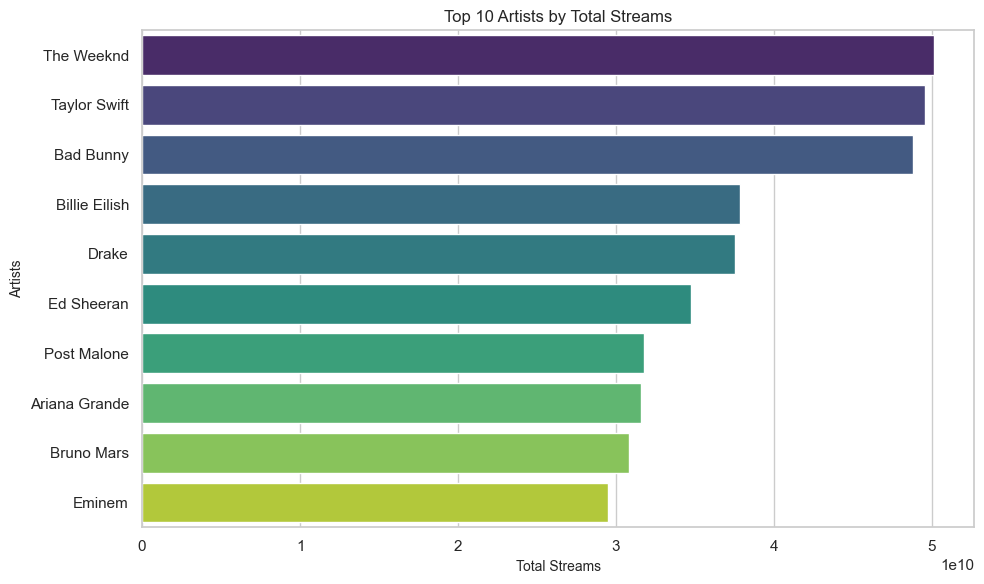

In [10]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.barplot(x=top_artists.values, y=top_artists.index, palette="viridis")

plt.title('Top 10 Artists by Total Streams')
plt.xlabel('Total Streams', fontsize=10)
plt.ylabel('Artists' , fontsize=10)

plt.tight_layout()
plt.show()

In [14]:
df["Daily Stream Percentage"] = (df["Daily"] / df["Streams"]) * 100

df.head()

,Streams,Daily,Artists,Track Name,Daily Stream Percentage
0,5341996137,1366661,The Weeknd,Blinding Lights,0.025583
1,4834446201,1390040,Ed Sheeran,Shape of You,0.028753
2,4482525861,2367040,The Neighbourhood,Sweater Weather,0.052806
3,4443548062,1794689,The Weeknd,Starboy,0.040389
4,4322346703,1641116,Harry Styles,As It Was,0.037968
